#Graphical Neural Network
1.Every node starts with some features
2.Each node collects(aggregates) information from its neighbors.
3.It combines that with its own info to update itself.
4.Repeat this for a few 'Layers'.

#Graph Convolution layer: Activation(Average[features of neighbors + itself],transformed weights)
1.Gathers the feature vectors of each node's neighbors(and itself).
2.Averages them 
3.Multiplies by learnable weight matrix (like neural network layer).
4.Applies a non-linerality(like ReLU)


CORA dataset(Research Papers)
1.Neural Network
2.Rule learning
3.Reinforcement learning 
4.Probabilitics methods
5.Theory
6.Genetic Algorithms
7.Case-Based  

Paper=2708
feature: 1433 each

nodes= Research papers 
edge = citations
features = info about each research paper(1433)


#Citation Network Paper Classification with Cora
#Data set is represented as graph
#Research Paper A --------> Research Paper B (Topic?)

In [30]:
%pip install torch torch-geometric scikit-learn pandas matplotlib seaborn networks -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Note: you may need to restart the kernel to use updated packages.


In [31]:
from torch_geometric.datasets import Planetoid

In [9]:
#Load Cora citations graph
#Planetoid is pytorch geometric dataset wrapper for Cora, CiteSeer, and PubMed[4]. Each paper is a node, each citation is an edge, x contains node features, and y contains topic labels. The provided masks define the train, validation and test nodes.


In [32]:
dataset = Planetoid(root='data/Planetoid', name='Cora')
data = dataset[0]

print(f"Number of Papers (Nodes) : {data.num_nodes}")
print(f"Number of Citations (Edges) : {data.num_edges}")
print(f"Features per paper : {data.num_node_features}")
print(f"Number of topics : {dataset.num_classes}")
print(f"Training Papers: {data.train_mask.sum()}")
print(f"Validation Papers: {data.val_mask.sum()}")
print(f"Testing Papers: {data.test_mask.sum()}")


Number of Papers (Nodes) : 2708
Number of Citations (Edges) : 10556
Features per paper : 1433
Number of topics : 7
Training Papers: 140
Validation Papers: 500
Testing Papers: 1000


In [11]:
#3.Inspect citation-network structure
#A node degree is the number of edges connected to a paper. Degree is a simple graph feature: highly connected papers may be more central to their topic, although degree alone is not enough for classification.

In [33]:
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


<Axes: xlabel='None', ylabel='count'>

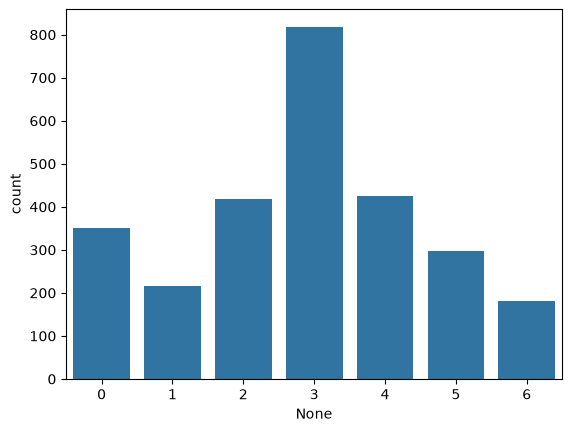

In [34]:
#We need to check for class imbalance
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()
sns.barplot(x=topic_counts.index, y=topic_counts)

In [14]:
#to remove imbalance we use class weight or smote


#BaseLine: TF-IDF-style features plus Random Forest
#The Cora features are binary for whether a vocabulary appears in a paper. TfidfTransformer reweights these columns so the words occuring in many papers receive less emphasis. We then add two easy graph features: degree and log-degree.
#This is a fair educational baseline, but it is not a text trained on raw abstracts. Its purpose is to answer. How well can we classify papers without message passing across the graph?

In [15]:
#cora dataset -----> Paper features + Paper Connections -----> prepare the data, degree, log ----> Random forest-----> Train on known paper -----> Predict topic of unknown paper ------> evaluate

In [35]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [36]:
#Reweight the supplies word indicators.
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf #Features

train_idx = data.train_mask.numpy()#Training research papers
val_idx = data.val_mask.numpy()
test_idx = data.test_mask.numpy()

X_train, y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx],y[test_idx]

rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', class_weight='balanced',random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [37]:
#Every time you need to create a baseline model then train 
#Evaluation
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Macro-F1: {f1_score(y_test, rf_pred, average='macro'):.4f}")

Accuracy: 0.5810
Macro-F1: 0.5698


<Axes: >

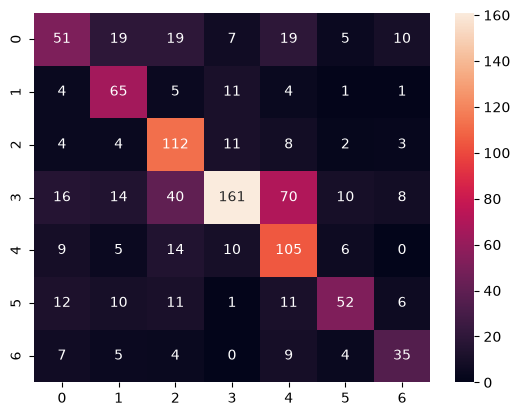

In [38]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')

5.Advanced model: a simple two-layer GCN
A GCN updates each paper by combining its own features with information from neighbouring papers. Here model has only two graph-convolution layers, a ReLU activation, and dropout. This keeps the code readable while demonstrating the central idea of graph neural networks.
GCNConv is Pytorch Geometric's implementaion of the graph convolution opertors

In [39]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv
import torch

class SimpleGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self,x,edge_index):
        x = self.conv1(x,edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training= self.training)
        x = self.conv2(x,edge_index)
        return x
model = SimpleGCN(
    input_dim=data.num_features,
    hidden_dim=32,
    output_dim= dataset.num_classes
)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
print(model)


SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [21]:
#Research Paper A -> 0, 1, 2, 3, 4, 5, 6

In [40]:
#Training of GCN model   #When training start dropout start
def train_one_epoch():
    model.train() #Training
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index)#x -> 2708 x 7
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    predictions = logits[mask].argmax(dim=1)
    accuracy = (predictions == data.y[mask]).float().mean().item()
    macro_f1 = f1_score(
        data.y[mask].numpy(),
        predictions.numpy(),
        average='macro'
    )
    return accuracy, macro_f1, predictions

In [23]:
#Predictions = [2,1,3,0]
#data.y[mask] = [2,0,3,1]
#(Actual)

#predictions == data.y[mask]
#[2,1,3,0] == [2,0,3,1]
#Result ---> [T, F, T, F]

#Result = [1,0,1,0].mean() 
#accuracy = 0.5


#Masking
#Papers ---> [Paper0, Paper1, Paper2, Paper3, Paper4]
#Train_Mask ---> [T, F, T, F, F]        T:Select this paper F:dont

In [41]:
losses, train_accuracies, val_accuracies = [], [], []
best_val_accuracy = 0.0
best_state = None

epoch_without_improvement = 0
patience = 20 #Stop i no improvement for this many epochs

for epoch in range(1, 201):
    loss = train_one_epoch()
    train_accuracy,_,_ = evaluate(data.train_mask)
    val_accuracy,_,_ = evaluate(data.val_mask)

    losses.append(loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)#0.70

    if val_accuracy > best_val_accuracy: #0.56 > 0.70
        best_val_accuracy = val_accuracy
        best_state = model.state_dict()
        epoch_without_improvement = 0
    else:
        epoch_without_improvement += 1

    if epoch_without_improvement >= patience:
        print(f'Early stopping at epoch {epoch}')
        break
    
    if epoch == 2 or epoch % 10 == 0:
        print(f"Epoch: {epoch:03d} | Loss: {loss:.4f}, Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} | Best Val Acc: {best_val_accuracy:.4f}")

#best state: structure+ learnable weights+ learnable biases


model.load_state_dict(best_state)
gcn_accuracy, gcn_f1, gcn_pred = evaluate(data.test_mask)

print(f"\nGCN test accuracy: {gcn_accuracy:.3f}")
print(f"GCN test macro-f1: {gcn_f1:.3f}")

Epoch: 002 | Loss: 1.7734, Train Acc: 0.8857 | Val Acc: 0.5760 | Best Val Acc: 0.5760
Epoch: 010 | Loss: 0.4318, Train Acc: 0.9857 | Val Acc: 0.7960 | Best Val Acc: 0.7960
Epoch: 020 | Loss: 0.0601, Train Acc: 1.0000 | Val Acc: 0.7840 | Best Val Acc: 0.8000
Epoch: 030 | Loss: 0.0231, Train Acc: 1.0000 | Val Acc: 0.7820 | Best Val Acc: 0.8000
Early stopping at epoch 33

GCN test accuracy: 0.787
GCN test macro-f1: 0.781


In [44]:
#Compare models
#Accuracy is the fraction of correct predictions. Macro-F1 gives every topic equal importance, which is useful when class sizes differ. The exact result can vary slightly across hardware, package versions and training runs.

<Axes: >

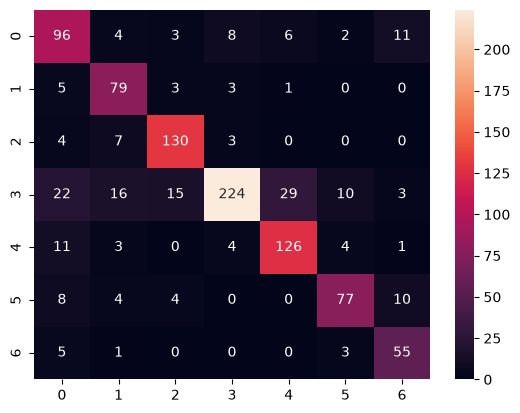

In [42]:
#Confusion Matrix for GCN Model.
sns.heatmap(
    confusion_matrix(data.y[data.test_mask].numpy(), gcn_pred.numpy()),
    annot=True,
    fmt='d'
)

In [43]:
results = pd.DataFrame({
    "Model": ["Random Forest", "GCN"],
    "Accuracy": [rf_accuracy, gcn_accuracy],
    "Macro-F1": [rf_f1, gcn_f1]
})

In [44]:
results

,Model,Accuracy,Macro-F1
0,Random Forest,0.581,0.569807
1,GCN,0.787,0.781456


In [28]:
#Learnings: RandomForest uses each paper's features independently, with degree as a small amount of graph context. The GCN performs message passing, allowing a paper's representation to be influenced by connecteed papers. When the GCN performs better, the result suggests that citation structure contains useful information about research topics.
#However, this is not proof that citations cause topic membership. The graph may contain homophily, dataset artifacts, or information leakage through the std benchmark split.For a stronger project, try CiteSeer or PubMed, compare different random seeds, report mean and std deviation over several runs, and test model using only graph features.

In [45]:
#ONNX ---> Open Neural Network Exchange -----> Model very fast and optimised
import torch 
%pip install onnxscript

#Set the model to evaluation mode
model.eval()

#Create dummy input for ONNX export
#The input 'x' has shape [num_nodes, num_features]
#The input 'edge_index' has shape[2, edge_index]
x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = 'simple_gcn_cora.onnx'

torch.onnx.export(
    model,                                          #1.Trained Model
    (x_dummy, edge_index_dummy),                    #2.Model input
    onnx_file_path,                                 #3.Where to save the onnx model
    export_params= True,                            #4.Store the trained parameter weights inside the model file.
    opset_version=18,                               #5.Changed opset_version to 18 to avoid version conversion issues.
    do_constant_folding= True,                      #6.Whether to execute constant folding for optimation.
    input_names= ['node_features', 'edge_indices'], #7.Input names
    output_names=['logits'] ,                       #8.Output names
    dynamic_axes={
        'node_features': {0: 'num_nodes'},          #9.Variable length for num_nodes
        'edge_indices': {1: 'num_edges'}            #10.Variable length for num_edges
    }
)


print(f'Model exported to {onnx_file_path}')

Note: you may need to restart the kernel to use updated packages.


C:\Users\tanma\AppData\Local\Temp\ipykernel_20268\4094625572.py:16: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0923 18:38:02.353000 20268 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0923 18:38:02.356000 20268 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align
W0923 18:38:02.358000 20268 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool
W0923 18:38:02.360000 20268 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::deform_conv2d


[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\tanma\anaconda3\envs\gnn_env\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to simple_gcn_cora.onnx
